# Fixed-Income ETF Fragility: Macro Stress, Liquidity, and the Cross-Section of Bond ETF Returns

Four testable hypotheses:
- **H1** — Macro shocks drive heterogeneous cross-sectional returns; sensitivity varies systematically across ETF characteristics
- **H2** — Structural characteristics (size, cost, age) explain return variation beyond broad category membership
- **H3** — Backward-looking fragility metrics predict forward downside outcomes (drawdown, volatility) — fragility has predictive validity
- **H4** — The fragility-to-drawdown relationship amplifies during high macro stress regimes; fragile ETFs are disproportionately punished

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import warnings
import numpy as np
import pandas as pd
import scipy.stats as scipy_stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

from src import config
from src.features.category import assign_category_bucket
from src.features.rolling_risk import add_rolling_risk_metrics
from src.features.forward_outcomes import add_forward_outcomes
from src.features.stress_index import add_stress_index

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 9,
})

## Setup

In [2]:
PANEL_MODE = 'offline'  # switch to 'live' after running the live pipeline

panel = pd.read_csv(config.core_panel_csv(PANEL_MODE), parse_dates=['Date', 'Inception'])
panel = panel.sort_values(['Symbol', 'Date']).reset_index(drop=True)

# Apply feature engineering if the panel pre-dates the Phase 2 build.
# When core_panel.csv is regenerated via the full pipeline these become no-ops.
if 'category_bucket' not in panel.columns:
    panel = assign_category_bucket(panel)
if 'stress_index' not in panel.columns:
    panel = add_stress_index(panel)
if 'vol_12w' not in panel.columns:
    panel = add_rolling_risk_metrics(panel)
if 'fwd_ret_4w' not in panel.columns:
    panel = add_forward_outcomes(panel)

print(f'Panel mode: {PANEL_MODE}  |  path: {config.core_panel_csv(PANEL_MODE)}')
print(f'Rows: {len(panel):,}   ETFs: {panel.Symbol.nunique():,}   '
      f'Weeks: {panel.Date.nunique():,}')
print(f'Date range: {panel.Date.min().date()} to {panel.Date.max().date()}')
print(f'Columns: {list(panel.columns)}')

panel['year'] = panel['Date'].dt.year

Panel mode: offline  |  path: data/processed/offline/core_panel.csv
Rows: 157,171   ETFs: 348   Weeks: 520
Date range: 2016-05-13 to 2026-04-24
Columns: ['Date', 'Symbol', 'Return', 'ANFCI', 'BAMLC0A0CM', 'DGS10', 'T10Y2Y', 'T5YIE', 'VIX', 'MOVE', 'GPR', 'd_ANFCI', 'd_BAMLC0A0CM', 'd_DGS10', 'd_T10Y2Y', 'd_T5YIE', 'd_VIX', 'd_MOVE', 'd_GPR', 'RF_w', 'Name', 'Assets', 'ETF Database Category', 'ER', 'Inception', 'RET_XS', 'age_years', 'Assets_clean', 'ER_clean', 'log_assets', 'category_bucket', 'stress_index', 'high_stress', 'vol_12w', 'var_12w_90', 'downside_vol_12w', 'maxdd_12w', 'es_12w_90', 'fwd_ret_4w', 'fwd_maxdd_12w', 'fwd_vol_12w']


## 1. Universe Overview

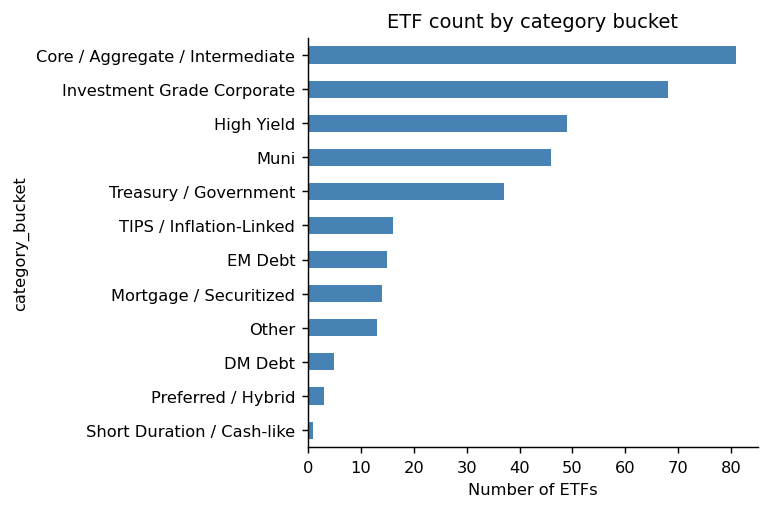

category_bucket
Core / Aggregate / Intermediate    81
Investment Grade Corporate         68
High Yield                         49
Muni                               46
Treasury / Government              37
TIPS / Inflation-Linked            16
EM Debt                            15
Mortgage / Securitized             14
Other                              13
DM Debt                             5
Preferred / Hybrid                  3
Short Duration / Cash-like          1


In [3]:
# ETF count per category (unique symbols)
etf_counts = (
    panel.drop_duplicates('Symbol')
    .groupby('category_bucket', dropna=False)
    .size()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(6, 4))
etf_counts.plot.barh(ax=ax, color='steelblue', edgecolor='none')
ax.set_xlabel('Number of ETFs')
ax.set_title('ETF count by category bucket')
plt.tight_layout()
plt.show()

print(etf_counts.sort_values(ascending=False).to_string())

## 2. Summary Statistics

In [4]:
STAT_COLS = ['Return', 'RET_XS', 'vol_12w', 'downside_vol_12w', 'maxdd_12w',
             'var_12w_90', 'es_12w_90', 'log_assets', 'ER_clean', 'age_years']

def fmt_stats(df):
    return df[STAT_COLS].describe(percentiles=[.1, .25, .5, .75, .9]).T[
        ['count', 'mean', 'std', '10%', '25%', '50%', '75%', '90%']
    ].round(4)

print('--- Full panel ---')
display(fmt_stats(panel))

--- Full panel ---


,count,mean,std,10%,25%,50%,75%,90%
Return,157171.0,0.0005,0.0126,-0.0087,-0.0024,0.0007,0.0038,0.0093
RET_XS,157171.0,0.0001,0.0126,-0.0092,-0.0029,0.0002,0.0034,0.0087
vol_12w,154735.0,0.0080,0.0099,0.0011,0.0028,0.0052,0.0094,0.0157
downside_vol_12w,131671.0,0.0054,0.0077,0.0008,0.0017,0.0033,0.0059,0.0109
maxdd_12w,154735.0,-0.0230,0.0347,-0.0560,-0.0271,-0.0115,-0.0043,-0.0012
var_12w_90,154735.0,-0.0081,0.0118,-0.0177,-0.0098,-0.0047,-0.0018,-0.0003
es_12w_90,154735.0,-0.0109,0.0153,-0.0228,-0.0129,-0.0067,-0.0028,-0.0008
log_assets,157171.0,20.7591,2.0890,18.0249,19.3736,20.7918,22.2690,23.5360
ER_clean,157171.0,0.0033,0.0039,0.0004,0.0010,0.0023,0.0041,0.0070
age_years,157171.0,7.7993,4.8461,1.7331,3.8823,7.1869,11.2936,14.7433


In [5]:
# Category-level return and risk summary
CAT_METRICS = ['Return', 'RET_XS', 'vol_12w', 'maxdd_12w', 'es_12w_90']
cat_summary = (
    panel.groupby('category_bucket')[CAT_METRICS]
    .mean()
    .sort_values('vol_12w', ascending=False)
    .round(4)
)
display(cat_summary)

,Return,RET_XS,vol_12w,maxdd_12w,es_12w_90
category_bucket,,,,,
Other,0.0003,-0.0002,0.0291,-0.0841,-0.0399
Preferred / Hybrid,0.0025,0.0020,0.0180,-0.0485,-0.0240
EM Debt,0.0006,0.0002,0.0107,-0.0315,-0.0148
DM Debt,-0.0000,-0.0005,0.0088,-0.0278,-0.0121
High Yield,0.0010,0.0005,0.0087,-0.0229,-0.0114
Treasury / Government,0.0002,-0.0003,0.0075,-0.0228,-0.0105
TIPS / Inflation-Linked,0.0006,0.0001,0.0071,-0.0197,-0.0097
Investment Grade Corporate,0.0006,0.0001,0.0068,-0.0195,-0.0093
Muni,0.0004,-0.0001,0.0060,-0.0180,-0.0084


## 3. Structural Variable Distributions

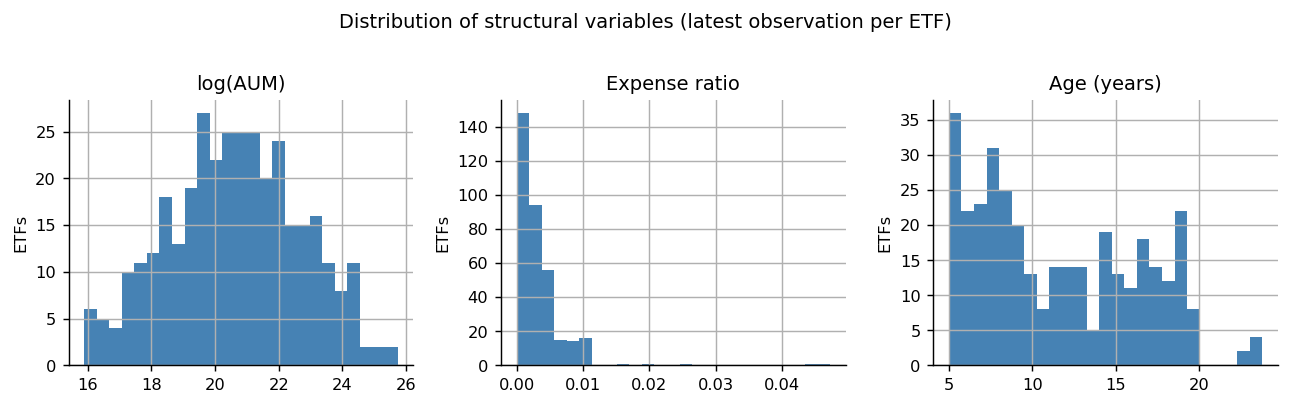

In [6]:
latest = panel.sort_values('Date').groupby('Symbol').tail(1)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, col, label in zip(
    axes,
    ['log_assets', 'ER_clean', 'age_years'],
    ['log(AUM)', 'Expense ratio', 'Age (years)']
):
    latest[col].dropna().hist(bins=25, ax=ax, color='steelblue', edgecolor='none')
    ax.set_title(label)
    ax.set_ylabel('ETFs')

plt.suptitle('Distribution of structural variables (latest observation per ETF)',
             y=1.02)
plt.tight_layout()
plt.show()

## 4. Macro Shock Correlations

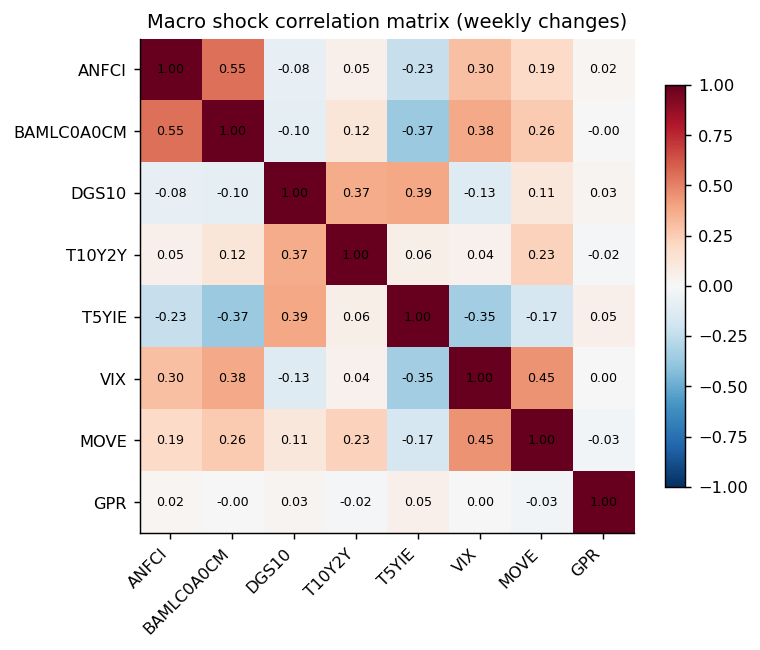

,d_ANFCI,d_BAMLC0A0CM,d_DGS10,d_T10Y2Y,d_T5YIE,d_VIX,d_MOVE,d_GPR
d_ANFCI,1.00,0.55,-0.08,0.05,-0.23,0.30,0.19,0.02
d_BAMLC0A0CM,0.55,1.00,-0.10,0.12,-0.37,0.38,0.26,-0.00
d_DGS10,-0.08,-0.10,1.00,0.37,0.39,-0.13,0.11,0.03
d_T10Y2Y,0.05,0.12,0.37,1.00,0.06,0.04,0.23,-0.02
d_T5YIE,-0.23,-0.37,0.39,0.06,1.00,-0.35,-0.17,0.05
d_VIX,0.30,0.38,-0.13,0.04,-0.35,1.00,0.45,0.00
d_MOVE,0.19,0.26,0.11,0.23,-0.17,0.45,1.00,-0.03
d_GPR,0.02,-0.00,0.03,-0.02,0.05,0.00,-0.03,1.00


In [7]:
MACRO_CHANGES = ['d_ANFCI', 'd_BAMLC0A0CM', 'd_DGS10', 'd_T10Y2Y',
                 'd_T5YIE', 'd_VIX', 'd_MOVE', 'd_GPR']

macro_weekly = panel[['Date'] + MACRO_CHANGES].drop_duplicates('Date')
corr = macro_weekly[MACRO_CHANGES].corr().round(2)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(MACRO_CHANGES)))
ax.set_yticks(range(len(MACRO_CHANGES)))
labels = [c.replace('d_', '') for c in MACRO_CHANGES]
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)
for i in range(len(MACRO_CHANGES)):
    for j in range(len(MACRO_CHANGES)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                fontsize=7, color='black')
ax.set_title('Macro shock correlation matrix (weekly changes)')
plt.tight_layout()
plt.show()

display(corr)

## 5. Stress Index

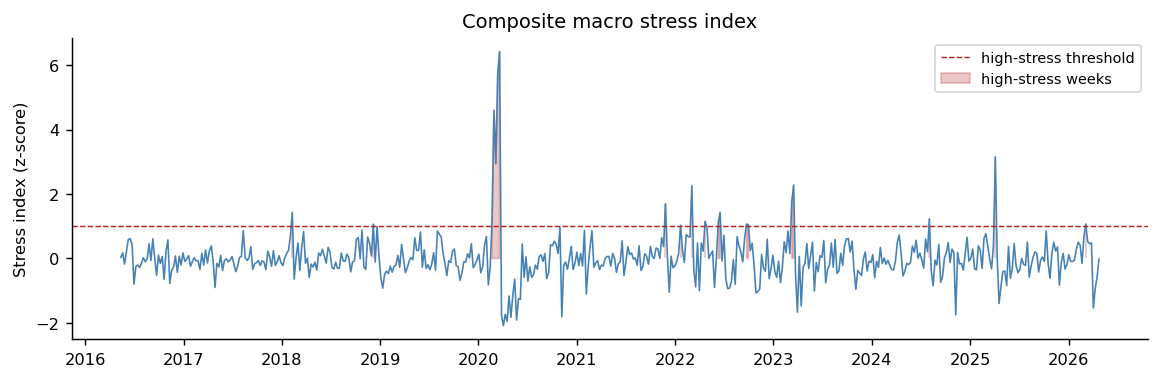

High-stress weeks: 20 of 520 (3.8%)


In [8]:
stress_ts = (
    panel[['Date', 'stress_index', 'high_stress']]
    .drop_duplicates('Date')
    .set_index('Date')
    .sort_index()
)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(stress_ts.index, stress_ts['stress_index'], lw=0.9, color='steelblue')
ax.axhline(1.0, color='firebrick', lw=0.8, ls='--', label='high-stress threshold')
ax.fill_between(stress_ts.index, stress_ts['stress_index'],
                where=stress_ts['high_stress'] == 1,
                alpha=0.25, color='firebrick', label='high-stress weeks')
ax.set_ylabel('Stress index (z-score)')
ax.set_title('Composite macro stress index')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

n_stress = stress_ts['high_stress'].sum()
pct_stress = n_stress / len(stress_ts) * 100
print(f'High-stress weeks: {n_stress} of {len(stress_ts)} ({pct_stress:.1f}%)')

## H1 + H2: Macro Sensitivity & Structural Heterogeneity

**H1**: Macro shocks (credit spreads, rate changes) significantly explain weekly bond ETF returns, with heterogeneous sensitivity across ETF types.
**H2**: Structural characteristics (AUM, expense ratio, age) explain cross-sectional variation beyond broad category membership.

Three progressive specifications isolate the contribution of macro factors (H1), category fixed effects, and structural characteristics (H2). F-tests confirm joint significance of each block.

In [9]:
reg_panel = panel.dropna(
    subset=['RET_XS', 'category_bucket', 'log_assets', 'ER_clean', 'age_years']
           + MACRO_CHANGES
).copy()
reg_panel = reg_panel[reg_panel['category_bucket'] != 'Other']

# Rescale GPR to z-score — raw scale (~0–500) produces near-zero display artifacts
reg_panel['d_GPR_z'] = ((reg_panel['d_GPR'] - reg_panel['d_GPR'].mean())
                         / reg_panel['d_GPR'].std())

MACRO_BLOCK  = ('d_ANFCI + d_BAMLC0A0CM + d_DGS10 + '
                'd_T10Y2Y + d_T5YIE + d_GPR_z')
STRUCT_BLOCK = 'log_assets + ER_clean + age_years'

kw = lambda df: dict(cov_type='cluster',
                     cov_kwds={'groups': df['Symbol']})

m1a = smf.ols(f'RET_XS ~ {MACRO_BLOCK}',
              data=reg_panel).fit(**kw(reg_panel))
m1b = smf.ols(f'RET_XS ~ {MACRO_BLOCK} + C(category_bucket)',
              data=reg_panel).fit(**kw(reg_panel))
m1c = smf.ols(f'RET_XS ~ {MACRO_BLOCK} + C(category_bucket) + {STRUCT_BLOCK}',
              data=reg_panel).fit(**kw(reg_panel))

tbl_m1 = summary_col(
    [m1a, m1b, m1c],
    model_names=['(1) Macro', '(2) +Cat FE', '(3) +Structural'],
    stars=True, float_format='%0.5f',
    regressor_order=['d_ANFCI', 'd_BAMLC0A0CM', 'd_DGS10',
                     'd_T10Y2Y', 'd_T5YIE', 'd_GPR_z',
                     'log_assets', 'ER_clean', 'age_years'],
    drop_omitted=True,
    info_dict={
        'N':       lambda x: f'{int(x.nobs):,}',
        'R²':      lambda x: f'{x.rsquared:.4f}',
        'Cat FE':  lambda x: 'Yes' if 'category_bucket' in x.model.formula else 'No',
    }
)
print(tbl_m1)
print('Note: d_GPR_z is the weekly GPR change standardized to z-score (raw scale ~0–500).')

print('\nR² increments:')
print(f'  (1) Macro only:           {m1a.rsquared:.4f}')
print(f'  (2) + Category FE:        {m1b.rsquared:.4f}'
      f'  (Δ = {m1b.rsquared - m1a.rsquared:+.4f})')
print(f'  (3) + Structural vars:    {m1c.rsquared:.4f}'
      f'  (Δ = {m1c.rsquared - m1b.rsquared:+.4f})')
print('  Note: macro block already explains ~41% of weekly return variance; category')
print('  and structural vars address forward risk, not contemporaneous sensitivity (see H3).')

# F-test: macro block adds beyond category FE
_m1b_ols = smf.ols(f'RET_XS ~ {MACRO_BLOCK} + C(category_bucket)',
                   data=reg_panel).fit()
_m1_cat  = smf.ols('RET_XS ~ C(category_bucket)',
                   data=reg_panel).fit()
f_stat, f_pval, _ = _m1b_ols.compare_f_test(_m1_cat)
print(f'\nF-test macro block beyond category FE (non-robust):'
      f' F = {f_stat:.2f}, p = {f_pval:.4f}')

_m1c_ols = smf.ols(
    f'RET_XS ~ {MACRO_BLOCK} + C(category_bucket) + {STRUCT_BLOCK}',
    data=reg_panel).fit()
f2_stat, f2_pval, _ = _m1c_ols.compare_f_test(_m1b_ols)
print(f'F-test structural vars beyond macro + category FE (non-robust):'
      f' F = {f2_stat:.2f}, p = {f2_pval:.4f}')

# ── VIF check ─────────────────────────────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor
import patsy

_, X_vif = patsy.dmatrices(f'RET_XS ~ {MACRO_BLOCK}',
                            data=reg_panel, return_type='dataframe')
vif_rows = [
    {'Variable': col, 'VIF': round(variance_inflation_factor(X_vif.values, i), 2)}
    for i, col in enumerate(X_vif.columns) if col != 'Intercept'
]
print('\nVIF — macro predictors in M1 spec (1):')
display(pd.DataFrame(vif_rows).set_index('Variable'))
print('VIF > 5: meaningful collinearity; > 10: severe.')
print('d_ANFCI positive sign may reflect collinearity with d_BAMLC0A0CM / d_DGS10.')



                (1) Macro  (2) +Cat FE (3) +Structural
------------------------------------------------------
d_ANFCI        0.01515***  0.01516***  0.01515***     
               (0.00203)   (0.00203)   (0.00203)      
d_BAMLC0A0CM   -0.05107*** -0.05107*** -0.05108***    
               (0.00228)   (0.00228)   (0.00228)      
d_DGS10        -0.04627*** -0.04626*** -0.04626***    
               (0.00173)   (0.00173)   (0.00173)      
d_T10Y2Y       0.00816***  0.00816***  0.00818***     
               (0.00097)   (0.00097)   (0.00097)      
d_T5YIE        0.00902***  0.00902***  0.00901***     
               (0.00075)   (0.00075)   (0.00075)      
d_GPR_z        -0.00004*** -0.00004*** -0.00003***    
               (0.00001)   (0.00001)   (0.00001)      
log_assets                             0.00005***     
                                       (0.00001)      
ER_clean                               0.01077**      
                                       (0.00496)      
age_years

,VIF
Variable,
d_ANFCI,1.45
d_BAMLC0A0CM,1.62
d_DGS10,1.35
d_T10Y2Y,1.17
d_T5YIE,1.37
d_GPR_z,1.01


VIF > 5: meaningful collinearity; > 10: severe.
d_ANFCI positive sign may reflect collinearity with d_BAMLC0A0CM / d_DGS10.


In [10]:
# Average macro betas by category from per-ETF time-series regressions
MACRO_SHOCKS = ['d_ANFCI', 'd_BAMLC0A0CM', 'd_DGS10', 'd_VIX', 'd_MOVE']

betas = []
for sym, grp in reg_panel.groupby('Symbol'):
    if len(grp) < 30:
        continue
    try:
        m = smf.ols(
            'RET_XS ~ ' + ' + '.join(MACRO_SHOCKS), data=grp
        ).fit()
        row = {'Symbol': sym,
               'category_bucket': grp['category_bucket'].iloc[0]}
        for s in MACRO_SHOCKS:
            row[s] = m.params.get(s, np.nan)
        betas.append(row)
    except Exception:
        pass

betas_df = pd.DataFrame(betas)

cat_betas = (
    betas_df.groupby('category_bucket')[MACRO_SHOCKS]
    .mean()
    .round(4)
)
print('Average macro betas by category:')
display(cat_betas)

Average macro betas by category:


,d_ANFCI,d_BAMLC0A0CM,d_DGS10,d_VIX,d_MOVE
category_bucket,,,,,
Core / Aggregate / Intermediate,0.0037,-0.0328,-0.0433,-0.0001,-0.0000
DM Debt,0.0041,-0.0263,-0.0455,-0.0002,-0.0000
EM Debt,-0.0251,-0.0627,-0.0419,-0.0006,-0.0002
High Yield,0.0205,-0.0792,-0.0233,-0.0007,-0.0001
Investment Grade Corporate,0.0354,-0.0716,-0.0456,-0.0000,-0.0000
Mortgage / Securitized,-0.0148,-0.0076,-0.0462,-0.0002,-0.0000
Muni,0.0306,-0.0607,-0.0378,0.0002,-0.0000
Preferred / Hybrid,-0.0121,-0.0810,-0.0234,-0.0029,-0.0001
Short Duration / Cash-like,0.0014,-0.0040,-0.0023,-0.0000,-0.0000


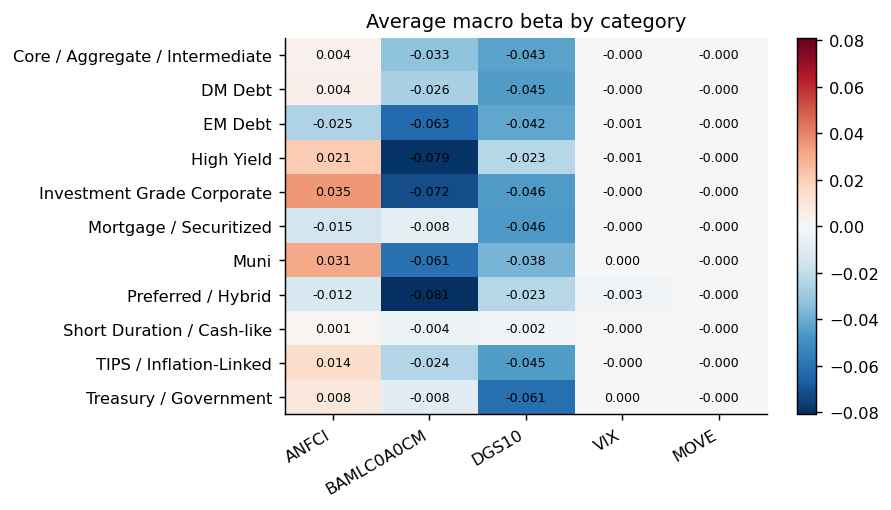

In [11]:
# Heatmap of category-average betas
fig, ax = plt.subplots(figsize=(7, 4))
vabs = cat_betas.abs().max().max()
im = ax.imshow(cat_betas.values, cmap='RdBu_r', vmin=-vabs, vmax=vabs,
               aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(MACRO_SHOCKS)))
ax.set_xticklabels([c.replace('d_', '') for c in MACRO_SHOCKS], rotation=30, ha='right')
ax.set_yticks(range(len(cat_betas)))
ax.set_yticklabels(cat_betas.index)
for i in range(len(cat_betas)):
    for j in range(len(MACRO_SHOCKS)):
        ax.text(j, i, f'{cat_betas.iloc[i, j]:.3f}', ha='center', va='center',
                fontsize=7)
ax.set_title('Average macro beta by category')
plt.tight_layout()
plt.show()

### Within-Category Beta Dispersion (H1)

H1 claims heterogeneous macro sensitivity **within** categories, not just between them.
Per-ETF OLS betas on `d_BAMLC0A0CM` test whether dispersion around the category mean is statistically non-zero. Bartlett test checks whether dispersion differs across categories.

In [12]:
# betas_df is produced in Cell 17 — per-ETF OLS betas
disp = (
    betas_df.groupby('category_bucket')['d_BAMLC0A0CM']
    .agg(n='count', mean='mean', std='std',
         p10=lambda x: x.quantile(0.1),
         p90=lambda x: x.quantile(0.9))
    .assign(iqr_90_10=lambda d: d['p90'] - d['p10'])
    .sort_values('std', ascending=False)
    .round(4)
)
display(disp)

# One-sample t-test: within each category, are betas dispersed around the cat mean?
print('\nWithin-category dispersion t-tests (H0: all ETF betas = category mean):')
rows = []
for cat, grp in betas_df.dropna(subset=['d_BAMLC0A0CM']).groupby('category_bucket'):
    demeaned = grp['d_BAMLC0A0CM'] - grp['d_BAMLC0A0CM'].mean()
    if len(demeaned) < 3:
        continue
    # F-test: variance of demeaned betas vs zero
    # Equivalent: t-test on abs(demeaned) > 0 isn't right;
    # instead use Levene/Bartlett or simply report the std and its SE
    se_std = grp['d_BAMLC0A0CM'].std() / np.sqrt(2 * (len(grp) - 1))
    t_disp = grp['d_BAMLC0A0CM'].std() / se_std
    rows.append({
        'Category':   cat,
        'N ETFs':     len(grp),
        'Std(beta)':  round(grp['d_BAMLC0A0CM'].std(), 4),
        'SE(std)':    round(se_std, 4),
        't':          round(t_disp, 2),
    })
display(pd.DataFrame(rows).set_index('Category'))

# Bartlett test: are within-category variances equal across categories?
# Rejecting this means categories differ in their beta dispersion as well as level
groups = [g['d_BAMLC0A0CM'].dropna().values
          for _, g in betas_df.dropna(subset=['d_BAMLC0A0CM']).groupby('category_bucket')
          if len(g) >= 3]
bart_stat, bart_p = scipy_stats.bartlett(*groups)
print(f'\nBartlett test (equal within-category variance): '
      f'stat={bart_stat:.2f}, p={bart_p:.4f}')


,n,mean,std,p10,p90,iqr_90_10
category_bucket,,,,,,
TIPS / Inflation-Linked,16,-0.0240,0.0405,-0.0429,-0.0061,0.0369
Investment Grade Corporate,68,-0.0716,0.0353,-0.1120,-0.0193,0.0928
Muni,46,-0.0607,0.0289,-0.0991,-0.0236,0.0755
High Yield,49,-0.0792,0.0257,-0.1023,-0.0481,0.0542
Treasury / Government,37,-0.0084,0.0252,-0.0285,0.0039,0.0325
EM Debt,15,-0.0627,0.0242,-0.0891,-0.0287,0.0604
Core / Aggregate / Intermediate,81,-0.0328,0.0219,-0.0656,-0.0130,0.0526
Preferred / Hybrid,3,-0.0810,0.0076,-0.0873,-0.0759,0.0114
DM Debt,5,-0.0263,0.0064,-0.0305,-0.0194,0.0111



Within-category dispersion t-tests (H0: all ETF betas = category mean):


,N ETFs,Std(beta),SE(std),t
Category,,,,
Core / Aggregate / Intermediate,81,0.0219,0.0017,12.65
DM Debt,5,0.0064,0.0023,2.83
EM Debt,15,0.0242,0.0046,5.29
High Yield,49,0.0257,0.0026,9.80
Investment Grade Corporate,68,0.0353,0.0031,11.58
Mortgage / Securitized,14,0.0054,0.0011,5.10
Muni,46,0.0289,0.0030,9.49
Preferred / Hybrid,3,0.0076,0.0038,2.00
TIPS / Inflation-Linked,16,0.0405,0.0074,5.48



Bartlett test (equal within-category variance): stat=63.32, p=0.0000


## H3: Fragility Predicts Forward Downside

**H3**: Backward-looking fragility metrics (`vol_12w`, `downside_vol_12w`, `maxdd_12w`) predict forward drawdowns and volatility — fragile ETFs have worse subsequent tail outcomes.

**Panel A** — progressive specs for `vol_12w → fwd_maxdd_12w`. R² increments show structural characteristics explain ~7× more variance than category labels (further H2 evidence).
**Panel B** — full spec across three outcomes; positive `vol_12w` on `fwd_ret_4w` shows no return penalty for fragility — the core risk-mispricing finding.
**Panel C** — robustness across all three fragility metrics.

In [13]:
FRAG_VARS    = ['vol_12w', 'downside_vol_12w', 'maxdd_12w']
STRUCT_VARS  = ['log_assets', 'ER_clean', 'age_years']
CONTROLS     = 'log_assets + ER_clean + age_years + C(category_bucket) + C(year)'
CONTROLS_CAT = 'log_assets + ER_clean + age_years + C(category_bucket)'

reg2 = panel.dropna(
    subset=['fwd_maxdd_12w', 'fwd_vol_12w', 'category_bucket', 'year']
           + FRAG_VARS + STRUCT_VARS
).copy()
reg2 = reg2[reg2['category_bucket'] != 'Other']

kw2 = lambda df: dict(cov_type='cluster', cov_kwds={'groups': df['Symbol']})

# ── Panel A: progressive specs (vol_12w → fwd_maxdd_12w) ─────────────────
m2p1 = smf.ols('fwd_maxdd_12w ~ vol_12w',
               data=reg2).fit(**kw2(reg2))
m2p2 = smf.ols('fwd_maxdd_12w ~ vol_12w + C(category_bucket)',
               data=reg2).fit(**kw2(reg2))
m2p3 = smf.ols(f'fwd_maxdd_12w ~ vol_12w + {CONTROLS}',
               data=reg2).fit(**kw2(reg2))

tbl_m2a = summary_col(
    [m2p1, m2p2, m2p3],
    model_names=['(1) Bare', '(2) +Cat FE', '(3) +Full'],
    stars=True, float_format='%0.4f',
    regressor_order=['vol_12w'] + STRUCT_VARS,
    drop_omitted=True,
    info_dict={
        'N':       lambda x: f'{int(x.nobs):,}',
        'R²':      lambda x: f'{x.rsquared:.4f}',
        'Cat FE':  lambda x: 'Yes' if 'category_bucket' in x.model.formula else 'No',
        'Year FE': lambda x: 'Yes' if 'year' in x.model.formula else 'No',
    }
)
print('Panel A: Progressive specs — outcome: fwd_maxdd_12w')
print(tbl_m2a)
print(f'R²: Bare={m2p1.rsquared:.4f}  '
      f'+CatFE={m2p2.rsquared:.4f} (Δ{m2p2.rsquared-m2p1.rsquared:+.4f})  '
      f'Full={m2p3.rsquared:.4f} (Δ{m2p3.rsquared-m2p2.rsquared:+.4f})')

# ── Panel B: full spec across three outcomes ──────────────────────────────
reg2_ret = panel.dropna(
    subset=['fwd_ret_4w', 'category_bucket', 'year', 'vol_12w'] + STRUCT_VARS
).copy()
reg2_ret = reg2_ret[reg2_ret['category_bucket'] != 'Other']

m2_dd  = m2p3
m2_vv  = smf.ols(f'fwd_vol_12w  ~ vol_12w + {CONTROLS}',
                 data=reg2).fit(**kw2(reg2))
m2_ret = smf.ols(f'fwd_ret_4w   ~ vol_12w + {CONTROLS}',
                 data=reg2_ret).fit(**kw2(reg2_ret))

tbl_m2b = summary_col(
    [m2_dd, m2_vv, m2_ret],
    model_names=['fwd_maxdd_12w', 'fwd_vol_12w', 'fwd_ret_4w'],
    stars=True, float_format='%0.5f',
    regressor_order=['vol_12w'] + STRUCT_VARS,
    drop_omitted=True,
    info_dict={
        'N':  lambda x: f'{int(x.nobs):,}',
        'R²': lambda x: f'{x.rsquared:.4f}',
    }
)
print('\nPanel B: Full spec across outcomes (Cat FE + Year FE in all)')
print(tbl_m2b)
print('Note: positive vol_12w coef on fwd_ret_4w = no return penalty for fragility.')


Panel A: Progressive specs — outcome: fwd_maxdd_12w

                (1) Bare  (2) +Cat FE (3) +Full 
------------------------------------------------
vol_12w        -1.0113*** -0.9326***  -0.6969***
               (0.1114)   (0.1075)    (0.1393)  
log_assets                            0.0008**  
                                      (0.0003)  
ER_clean                              -0.4262***
                                      (0.1102)  
age_years                             -0.0005***
                                      (0.0002)  
R-squared      0.0870     0.1003      0.1989    
R-squared Adj. 0.0870     0.1002      0.1987    
Cat FE         No         Yes         Yes       
N              121,965    121,965     121,965   
R²             0.0870     0.1003      0.1989    
Year FE        No         No          Yes       
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01
R²: Bare=0.0870  +CatFE=0.1003 (Δ+0.0133)  Full=0.1989 (Δ+0.0986)

Panel B: Full spec across outcomes (C

In [14]:
# Panel C: robustness across fragility metrics (outcome: fwd_maxdd_12w)
m2a = smf.ols(f'fwd_maxdd_12w ~ vol_12w + {CONTROLS}',
              data=reg2).fit(**kw2(reg2))
m2b = smf.ols(f'fwd_maxdd_12w ~ downside_vol_12w + {CONTROLS}',
              data=reg2).fit(**kw2(reg2))
m2c = smf.ols(f'fwd_maxdd_12w ~ maxdd_12w + {CONTROLS}',
              data=reg2).fit(**kw2(reg2))
m2d = smf.ols(
    f'fwd_maxdd_12w ~ vol_12w + downside_vol_12w + maxdd_12w + {CONTROLS}',
    data=reg2).fit(**kw2(reg2))

tbl_m2c = summary_col(
    [m2a, m2b, m2c, m2d],
    model_names=['(1) vol', '(2) d.vol', '(3) mdd', '(4) combined'],
    stars=True, float_format='%0.4f',
    regressor_order=FRAG_VARS + STRUCT_VARS,
    drop_omitted=True,
    info_dict={
        'N':       lambda x: f'{int(x.nobs):,}',
        'R²':      lambda x: f'{x.rsquared:.4f}',
        'Cat FE':  lambda x: 'Yes',
        'Year FE': lambda x: 'Yes',
    }
)
print('Panel C: Robustness across fragility metrics — outcome: fwd_maxdd_12w')
print(tbl_m2c)
print('Note: col (4) combined spec shows sign reversal on vol_12w / downside_vol_12w due')
print('to high collinearity between the two measures (corr ~0.9+). Cols (1)–(3) are the')
print('primary results; col (4) confirms joint significance but coefficients are unreliable.')


Panel C: Robustness across fragility metrics — outcome: fwd_maxdd_12w

                  (1) vol   (2) d.vol   (3) mdd   (4) combined
--------------------------------------------------------------
vol_12w          -0.6969***                       -1.5806***  
                 (0.1393)                         (0.2265)    
downside_vol_12w            -0.4822***            1.3963***   
                            (0.1330)              (0.1447)    
maxdd_12w                              0.1490***  0.0608***   
                                       (0.0308)   (0.0137)    
log_assets       0.0008**   0.0009**   0.0009**   0.0007**    
                 (0.0003)   (0.0004)   (0.0004)   (0.0003)    
ER_clean         -0.4262*** -0.4900*** -0.4609*** -0.3986***  
                 (0.1102)   (0.1288)   (0.1206)   (0.1008)    
age_years        -0.0005*** -0.0005*** -0.0005*** -0.0004***  
                 (0.0002)   (0.0002)   (0.0002)   (0.0001)    
R-squared        0.1989     0.1777     0.1865  

### Decile Sort: Forward Outcomes by Fragility

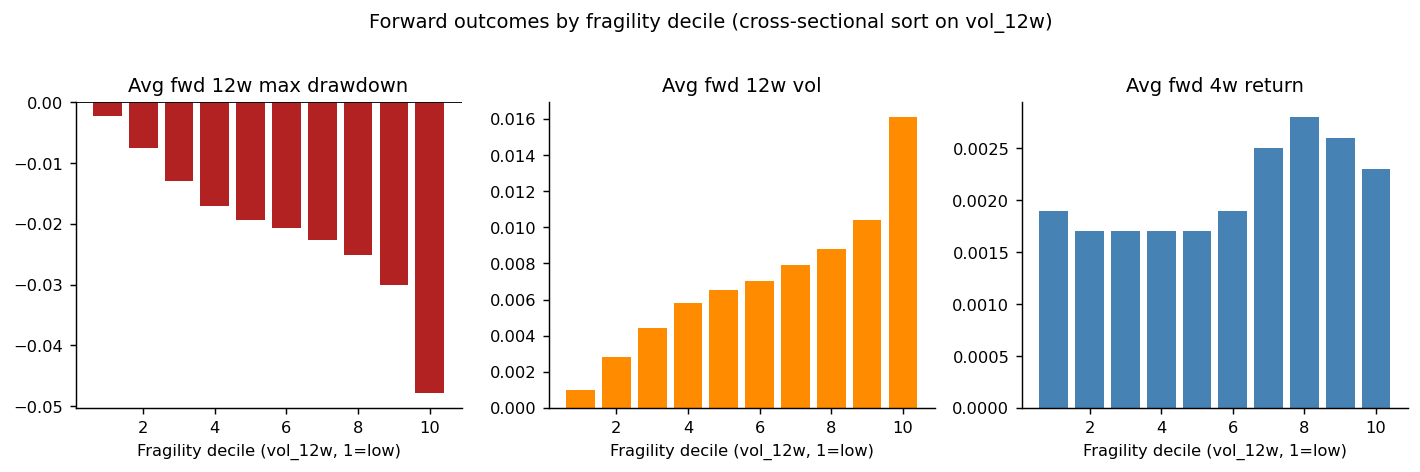

,fwd_maxdd_12w,fwd_vol_12w,fwd_ret_4w
frag_decile,,,
1,-0.0022,0.0010,0.0019
2,-0.0075,0.0028,0.0017
3,-0.0129,0.0044,0.0017
4,-0.0171,0.0058,0.0017
5,-0.0194,0.0065,0.0017
6,-0.0207,0.0070,0.0019
7,-0.0226,0.0079,0.0025
8,-0.0251,0.0088,0.0028
9,-0.0300,0.0104,0.0026


In [15]:
decile_data = panel.dropna(subset=['vol_12w', 'fwd_maxdd_12w']).copy()
decile_data = decile_data[decile_data['category_bucket'] != 'Other']

# Decile rank vol_12w within each week (cross-sectional sort)
decile_data['frag_decile'] = (
    decile_data.groupby('Date')['vol_12w']
    .transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') + 1)
)

decile_summary = (
    decile_data.groupby('frag_decile')[['fwd_maxdd_12w', 'fwd_vol_12w', 'fwd_ret_4w']]
    .mean()
    .round(4)
)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, col, title, color in zip(
    axes,
    ['fwd_maxdd_12w', 'fwd_vol_12w', 'fwd_ret_4w'],
    ['Avg fwd 12w max drawdown', 'Avg fwd 12w vol', 'Avg fwd 4w return'],
    ['firebrick', 'darkorange', 'steelblue']
):
    ax.bar(decile_summary.index, decile_summary[col], color=color, edgecolor='none')
    ax.set_xlabel('Fragility decile (vol_12w, 1=low)')
    ax.set_title(title)
    ax.axhline(0, color='black', lw=0.5)

plt.suptitle('Forward outcomes by fragility decile (cross-sectional sort on vol_12w)',
             y=1.02)
plt.tight_layout()
plt.show()

display(decile_summary)

### Robustness: Two-Way Clustered Standard Errors (CGM 2011)

Forward outcome windows at *t* and *t+1* overlap by 11 of 12 weeks, inducing serial correlation that Symbol-only clustering may understate. Cameron-Gelbach-Miller (2011): **V₂ = V(Symbol) + V(Date) − V(HC1)**.

In [16]:
def twoway_cluster_se(formula, data, col1, col2):
    """
    Returns (params, se_2way) using the CGM (2011) two-way cluster estimator.
    Fits the same OLS model three times (same point estimates, different SEs).
    """
    model  = smf.ols(formula, data=data)
    r_c1   = model.fit(cov_type='cluster', cov_kwds={'groups': data[col1]})
    r_c2   = model.fit(cov_type='cluster', cov_kwds={'groups': data[col2]})
    r_hc1  = model.fit(cov_type='HC1')

    V = (r_c1.cov_params().values
         + r_c2.cov_params().values
         - r_hc1.cov_params().values)

    # Project to nearest PSD (negative eigenvalues can appear in finite samples)
    eigvals, eigvecs = np.linalg.eigh(V)
    V_psd = eigvecs @ np.diag(np.maximum(eigvals, 0)) @ eigvecs.T

    return r_c1.params, np.sqrt(np.diag(V_psd)), r_c1


# Run M2 spec (1): vol_12w only — our primary fragility predictor
formula_spec1 = f'fwd_maxdd_12w ~ vol_12w + {CONTROLS}'

params_sym, se_sym, r_sym = (
    smf.ols(formula_spec1, data=reg2).fit(
        cov_type='cluster', cov_kwds={'groups': reg2['Symbol']}
    ).params,
    np.sqrt(np.diag(smf.ols(formula_spec1, data=reg2).fit(
        cov_type='cluster', cov_kwds={'groups': reg2['Symbol']}
    ).cov_params().values)),
    smf.ols(formula_spec1, data=reg2).fit(
        cov_type='cluster', cov_kwds={'groups': reg2['Symbol']}),
)
params_2w, se_2w, _ = twoway_cluster_se(formula_spec1, reg2, 'Symbol', 'Date')

KEY_VARS = ['vol_12w', 'log_assets', 'ER_clean', 'age_years']
rows = []
for v in KEY_VARS:
    coef  = params_sym[v]
    se_s  = se_sym[list(params_sym.index).index(v)]
    se_d  = se_2w[list(params_2w.index).index(v)]
    rows.append({
        'Variable':      v,
        'Coef':          round(coef, 5),
        'SE (Symbol)':   round(se_s, 5),
        't (Symbol)':    round(coef / se_s, 2),
        'SE (Sym+Date)': round(se_d, 5),
        't (Sym+Date)':  round(coef / se_d, 2),
        'SE inflation':  f'{se_d / se_s:.2f}x',
    })

display(pd.DataFrame(rows).set_index('Variable'))


,Coef,SE (Symbol),t (Symbol),SE (Sym+Date),t (Sym+Date),SE inflation
Variable,,,,,,
vol_12w,-0.69694,0.13928,-5.00,0.21489,-3.24,1.54x
log_assets,0.00080,0.00032,2.50,0.00032,2.49,1.01x
ER_clean,-0.42617,0.11023,-3.87,0.11234,-3.79,1.02x
age_years,-0.00045,0.00016,-2.85,0.00016,-2.81,1.02x


### Robustness: Fama-MacBeth Spearman Rank Correlation

Pooled Spearman ignores panel structure and inflates sample size. Instead: compute cross-sectional Spearman ρ between `vol_12w` and `fwd_maxdd_12w` within each week, then t-test whether the mean weekly ρ differs from zero. Degrees of freedom = number of weeks, not ETF-weeks.

In [17]:
from scipy import stats as scipy_stats

def weekly_spearman(df, x_col, y_col, min_obs=15):
    rhos = []
    for _, grp in df.dropna(subset=[x_col, y_col]).groupby('Date'):
        if len(grp) >= min_obs:
            rho, _ = scipy_stats.spearmanr(grp[x_col], grp[y_col])
            rhos.append(rho)
    s = pd.Series(rhos)
    mean_rho = s.mean()
    t_stat   = mean_rho / (s.std() / np.sqrt(len(s)))
    p_val    = 2 * scipy_stats.t.sf(abs(t_stat), df=len(s) - 1)
    return mean_rho, t_stat, p_val, len(s)


# Test all three outcomes, full sample and high-stress
outcomes = ['fwd_maxdd_12w', 'fwd_vol_12w', 'fwd_ret_4w']
rows = []
for outcome in outcomes:
    full  = panel[panel['category_bucket'] != 'Other']
    stress = full[full['high_stress'] == 1]

    rho_f,  t_f,  p_f,  n_f  = weekly_spearman(full,   'vol_12w', outcome)
    rho_s,  t_s,  p_s,  n_s  = weekly_spearman(stress, 'vol_12w', outcome)

    def stars(p):
        return '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))

    rows.append({
        'Outcome':           outcome,
        'rho (full)':        round(rho_f, 3),
        't (full)':          f'{t_f:.2f}{stars(p_f)}',
        'Weeks (full)':      n_f,
        'rho (stress)':      round(rho_s, 3),
        't (stress)':        f'{t_s:.2f}{stars(p_s)}',
        'Weeks (stress)':    n_s,
    })

display(pd.DataFrame(rows).set_index('Outcome'))
print('t-stats use weekly Spearman rho as the unit of observation (Fama-MacBeth style).')


,rho (full),t (full),Weeks (full),rho (stress),t (stress),Weeks (stress)
Outcome,,,,,,
fwd_maxdd_12w,-0.764,-152.53***,501,-0.721,-20.07***,19
fwd_vol_12w,0.863,242.46***,501,0.811,22.57***,19
fwd_ret_4w,0.080,3.57***,509,0.003,0.04,20


t-stats use weekly Spearman rho as the unit of observation (Fama-MacBeth style).


### Robustness: Pre-2022 vs. Post-2022 Subsample (H3)

The portfolio tilt chart shows 2022 doing heavy lifting. This tests whether `vol_12w → fwd_maxdd_12w` holds pre-2022 (low-rate, COVID environment) versus post-2022 (rate hike cycle). If H3 is regime-specific, the coefficient should be insignificant or opposite in the earlier period.

In [18]:
print(f'reg2 rows: {len(reg2):,}  year range: {reg2["year"].min()}–{reg2["year"].max()}')
print(reg2['year'].value_counts().sort_index())

# The current core_panel.csv has rolling-risk metrics (vol_12w etc.) starting from
# 2023 — a true pre/post-2022 split requires regenerating core_panel.csv via:
#   py -3.12 -m src.pipelines.build_core_panel
# For now: split on the median available year as a within-window stability check.

mid_year = int(reg2['year'].median())
reg2_early = reg2[reg2['year'] <= mid_year].copy()
reg2_late  = reg2[reg2['year'] >  mid_year].copy()
print(f'\nSplit: early (≤{mid_year}) n={len(reg2_early):,} | late (>{mid_year}) n={len(reg2_late):,}')

SIMPLE = 'log_assets + ER_clean + age_years'

m2_early  = smf.ols(f'fwd_maxdd_12w ~ vol_12w + {SIMPLE}',
                    data=reg2_early).fit(**kw2(reg2_early))
m2_late   = smf.ols(f'fwd_maxdd_12w ~ vol_12w + {SIMPLE}',
                    data=reg2_late).fit(**kw2(reg2_late))
m2_full_s = smf.ols(f'fwd_maxdd_12w ~ vol_12w + {SIMPLE}',
                    data=reg2).fit(**kw2(reg2))

tbl_sub = summary_col(
    [m2_early, m2_late, m2_full_s],
    model_names=[f'≤{mid_year}', f'>{mid_year}', 'Full'],
    stars=True, float_format='%0.4f',
    regressor_order=['vol_12w'] + STRUCT_VARS,
    drop_omitted=True,
    info_dict={
        'N':  lambda x: f'{int(x.nobs):,}',
        'R²': lambda x: f'{x.rsquared:.4f}',
    }
)
print(f'\nH3 within-window stability: vol_12w → fwd_maxdd_12w')
print(f'(structural controls only; no category FE to ensure cross-period comparability)')
print(tbl_sub)

print('\nvol_12w coefficient by period:')
for lbl, m in [(f'≤{mid_year}  ', m2_early),
               (f'>{mid_year}  ', m2_late),
               ('Full     ', m2_full_s)]:
    coef = m.params['vol_12w']
    se   = m.bse['vol_12w']
    t    = coef / se
    print(f'  {lbl}: coef = {coef:.4f}  SE = {se:.4f}  t = {t:.2f}  N = {int(m.nobs):,}')


reg2 rows: 121,965  year range: 2016–2026
year
2016     4012
2017     8807
2018    10486
2019     9188
2020    11760
2021    15556
2022    17082
2023    15433
2024    14605
2025    13717
2026     1319
Name: count, dtype: int64

Split: early (≤2022) n=76,891 | late (>2022) n=45,074

H3 within-window stability: vol_12w → fwd_maxdd_12w
(structural controls only; no category FE to ensure cross-period comparability)

                 ≤2022      >2022       Full   
-----------------------------------------------
vol_12w        -0.7557*** -2.0666*** -0.9792***
               (0.1003)   (0.1038)   (0.1135)  
log_assets     0.0013***  0.0002     0.0004*   
               (0.0004)   (0.0001)   (0.0002)  
ER_clean       -0.6070*** -0.1279**  -0.3781***
               (0.1696)   (0.0505)   (0.1100)  
age_years      -0.0009*** -0.0002*** -0.0003***
               (0.0002)   (0.0001)   (0.0001)  
R-squared      0.0770     0.3472     0.0923    
R-squared Adj. 0.0769     0.3472     0.0922    
N       

## H4: Stress Regime Amplification

**H4**: The fragility-to-drawdown relationship amplifies during high macro stress. Fragile ETFs are disproportionately punished when the composite stress index exceeds one standard deviation.

Four columns: **(1)** additive baseline, **(2)** binary interaction `vol_12w × high_stress`, **(3)** continuous interaction `vol_12w × stress_index`, **(4a/4b)** split-sample coefficient comparison.

In [19]:
reg3 = panel.dropna(
    subset=['fwd_maxdd_12w', 'category_bucket', 'high_stress',
            'stress_index', 'year'] + FRAG_VARS + STRUCT_VARS
).copy()
reg3 = reg3[reg3['category_bucket'] != 'Other']

kw3 = lambda df: dict(cov_type='cluster', cov_kwds={'groups': df['Symbol']})

# (1) Additive baseline
m3a = smf.ols(
    f'fwd_maxdd_12w ~ vol_12w + high_stress + '
    f'downside_vol_12w + maxdd_12w + {CONTROLS}',
    data=reg3).fit(**kw3(reg3))

# (2) Binary interaction
m3b = smf.ols(
    f'fwd_maxdd_12w ~ vol_12w * high_stress + '
    f'downside_vol_12w + maxdd_12w + {CONTROLS}',
    data=reg3).fit(**kw3(reg3))

# (3) Continuous stress_index interaction
m3c = smf.ols(
    f'fwd_maxdd_12w ~ vol_12w * stress_index + '
    f'downside_vol_12w + maxdd_12w + {CONTROLS}',
    data=reg3).fit(**kw3(reg3))

# (4a/4b) Split sample: CONTROLS_CAT only (no year FE) to avoid
# collinearity in the small stress subsample
reg3_ns = reg3[reg3['high_stress'] == 0].copy()
reg3_s  = reg3[reg3['high_stress'] == 1].copy()

m3_ns = smf.ols(
    f'fwd_maxdd_12w ~ vol_12w + downside_vol_12w + maxdd_12w + {CONTROLS_CAT}',
    data=reg3_ns).fit(**kw3(reg3_ns))
m3_s  = smf.ols(
    f'fwd_maxdd_12w ~ vol_12w + downside_vol_12w + maxdd_12w + {CONTROLS_CAT}',
    data=reg3_s ).fit(**kw3(reg3_s))

tbl_m3 = summary_col(
    [m3a, m3b, m3c, m3_ns, m3_s],
    model_names=['(1) Additive', '(2) Binary×',
                 '(3) Cont.×', '(4a) Low-stress', '(4b) High-stress'],
    stars=True, float_format='%0.4f',
    regressor_order=[
        'vol_12w', 'high_stress', 'vol_12w:high_stress',
        'stress_index', 'vol_12w:stress_index',
        'downside_vol_12w', 'maxdd_12w',
    ] + STRUCT_VARS,
    drop_omitted=True,
    info_dict={
        'N':        lambda x: f'{int(x.nobs):,}',
        'R²':       lambda x: f'{x.rsquared:.4f}',
        'Sample':   lambda x: 'Full',
    }
)
print(tbl_m3)

# Direct coefficient comparison across regimes
print('\nvol_12w coefficient by regime (split-sample):')
for lbl, m in [('Low-stress  (4a)', m3_ns), ('High-stress (4b)', m3_s)]:
    coef = m.params['vol_12w']
    se   = m.bse['vol_12w']
    t    = coef / se
    print(f'  {lbl}:  coef = {coef:.4f}  SE = {se:.4f}  t = {t:.2f}')

# Amplification ratio: how much larger is the coefficient during stress?
amp = m3_s.params['vol_12w'] / m3_ns.params['vol_12w']
print(f'\nAmplification ratio (stress / non-stress): {amp:.2f}x')



                     (1) Additive (2) Binary× (3) Cont.× (4a) Low-stress (4b) High-stress
-----------------------------------------------------------------------------------------
vol_12w              -1.6163***   -1.6287***  -1.8705*** -1.6824***      -1.6361***      
                     (0.2246)     (0.2250)    (0.2225)   (0.1860)        (0.2886)        
high_stress          -0.0061***   -0.0041***                                             
                     (0.0005)     (0.0009)                                               
vol_12w:high_stress               -0.1985***                                             
                                  (0.0626)                                               
stress_index                                  -0.0004                                    
                                              (0.0003)                                   
vol_12w:stress_index                          -0.2263***                                 
         

### Stress-Conditional Decile Sort (H4, Non-Parametric)

Same cross-sectional sort on `vol_12w`, restricted to `high_stress == 1` weeks.
Tests whether the D1–D10 drawdown spread widens during stress (H4, non-parametric).

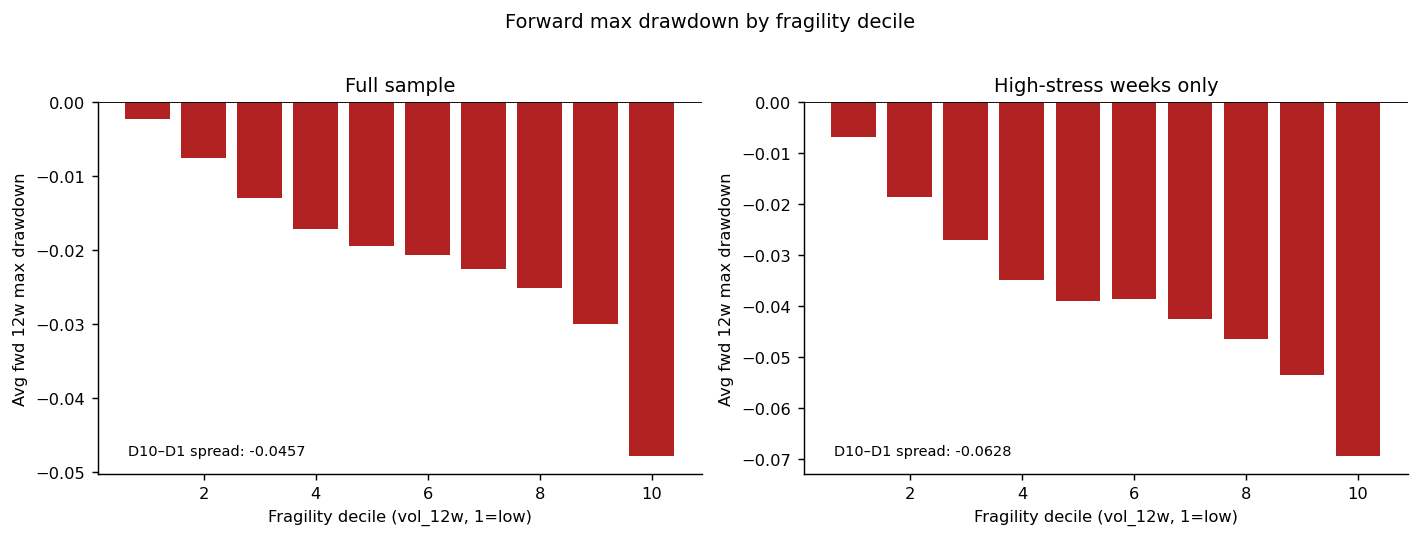

,Full sample,High stress,Amplification
frag_decile,,,
1,-0.0022,-0.0067,3.0455
2,-0.0075,-0.0185,2.4667
3,-0.0129,-0.0271,2.1008
4,-0.0171,-0.0349,2.0409
5,-0.0194,-0.0390,2.0103
6,-0.0207,-0.0387,1.8696
7,-0.0226,-0.0426,1.8850
8,-0.0251,-0.0464,1.8486
9,-0.0300,-0.0536,1.7867


In [20]:
stress_decile_data = decile_data[decile_data['high_stress'] == 1].copy()
stress_decile_data['frag_decile'] = (
    stress_decile_data.groupby('Date')['vol_12w']
    .transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') + 1)
)
decile_stress = (
    stress_decile_data
    .groupby('frag_decile')[['fwd_maxdd_12w', 'fwd_vol_12w', 'fwd_ret_4w']]
    .mean().round(4)
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, data, title in zip(
    axes,
    [decile_summary, decile_stress],
    ['Full sample', 'High-stress weeks only']
):
    ax.bar(data.index, data['fwd_maxdd_12w'], color='firebrick', edgecolor='none')
    ax.set_xlabel('Fragility decile (vol_12w, 1=low)')
    ax.set_ylabel('Avg fwd 12w max drawdown')
    ax.set_title(title)
    ax.axhline(0, color='black', lw=0.5)
    spread = data['fwd_maxdd_12w'].iloc[-1] - data['fwd_maxdd_12w'].iloc[0]
    ax.text(0.05, 0.05, f'D10–D1 spread: {spread:.4f}',
            transform=ax.transAxes, fontsize=8)

plt.suptitle('Forward max drawdown by fragility decile', y=1.02)
plt.tight_layout()
plt.show()

comparison = (
    decile_summary[['fwd_maxdd_12w']]
    .rename(columns={'fwd_maxdd_12w': 'Full sample'})
    .join(decile_stress[['fwd_maxdd_12w']]
          .rename(columns={'fwd_maxdd_12w': 'High stress'}))
)
comparison['Amplification'] = (comparison['High stress'] /
                                comparison['Full sample'])
display(comparison.round(4))


### Return per Unit of Max Drawdown — Full Sample vs. Stress (H4)

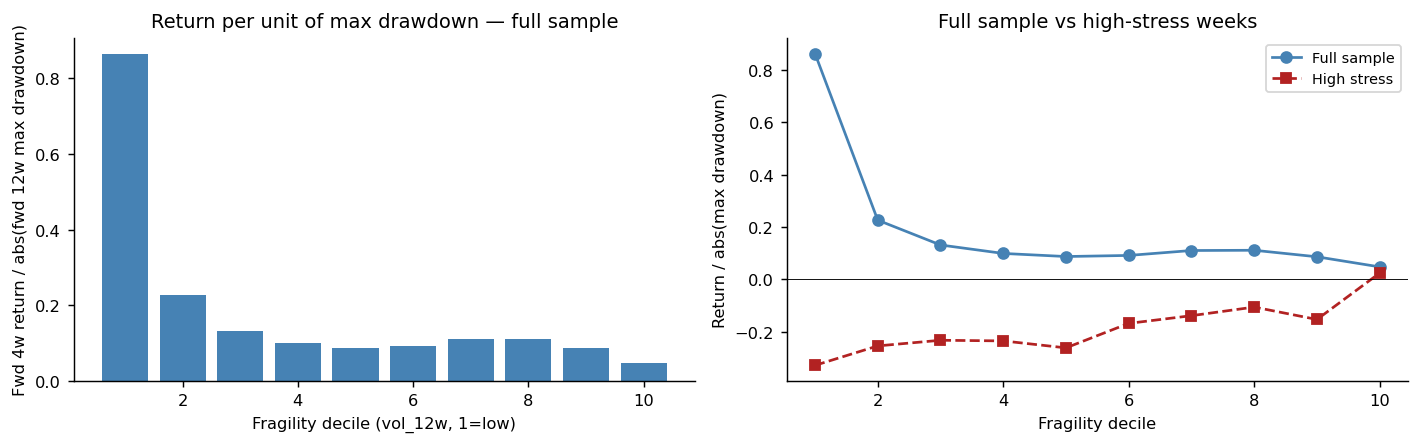

,fwd_ret_4w,fwd_maxdd_12w,ret_per_dd
frag_decile,,,
1,0.0019,-0.0022,0.8636
2,0.0017,-0.0075,0.2267
3,0.0017,-0.0129,0.1318
4,0.0017,-0.0171,0.0994
5,0.0017,-0.0194,0.0876
6,0.0019,-0.0207,0.0918
7,0.0025,-0.0226,0.1106
8,0.0028,-0.0251,0.1116
9,0.0026,-0.0300,0.0867


In [21]:
calmar = decile_summary[['fwd_ret_4w', 'fwd_maxdd_12w']].copy()
calmar['ret_per_dd'] = calmar['fwd_ret_4w'] / calmar['fwd_maxdd_12w'].abs()

calmar_stress = decile_stress[['fwd_ret_4w', 'fwd_maxdd_12w']].copy()
calmar_stress['ret_per_dd'] = (calmar_stress['fwd_ret_4w'] /
                               calmar_stress['fwd_maxdd_12w'].abs())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].bar(calmar.index, calmar['ret_per_dd'],
            color='steelblue', edgecolor='none')
axes[0].set_xlabel('Fragility decile (vol_12w, 1=low)')
axes[0].set_ylabel('Fwd 4w return / abs(fwd 12w max drawdown)')
axes[0].set_title('Return per unit of max drawdown — full sample')
axes[0].axhline(0, color='black', lw=0.5)

axes[1].plot(calmar.index, calmar['ret_per_dd'],
             marker='o', label='Full sample', color='steelblue')
axes[1].plot(calmar_stress.index, calmar_stress['ret_per_dd'],
             marker='s', label='High stress', color='firebrick', ls='--')
axes[1].set_xlabel('Fragility decile')
axes[1].set_ylabel('Return / abs(max drawdown)')
axes[1].set_title('Full sample vs high-stress weeks')
axes[1].legend(fontsize=8)
axes[1].axhline(0, color='black', lw=0.5)

plt.tight_layout()
plt.show()

display(calmar.round(4))


### Portfolio Tilt: Exclude Top-Fragility Quartile (H4, Practical)

Does screening out the most fragile 25% of ETFs reduce drawdowns specifically during stressed periods?

- **Naive EW**: equal-weight all non-Other ETFs with valid `vol_12w` each week
- **Tilt EW**: equal-weight only the bottom 75% by `vol_12w` (drop top fragility quartile)

The paired t-test isolates whether the tilt advantage is stress-specific — the direct practical statement of H4.

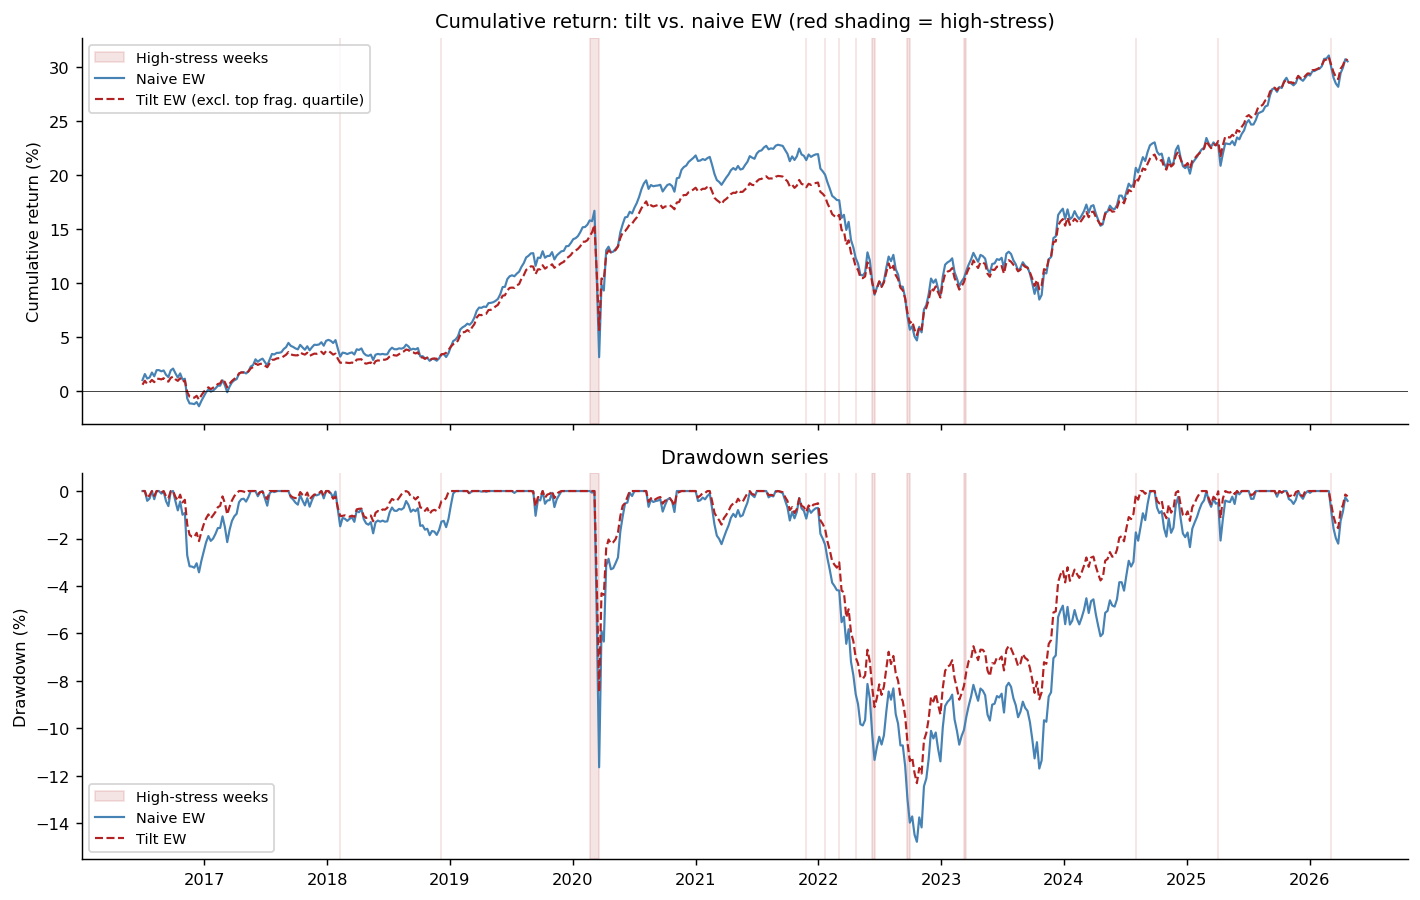

Portfolio tilt summary: full-sample returns are annualized; high-stress returns are cumulative.


,Regime,Portfolio/test,Return,Max DD,t-stat,p-value,N Weeks
0,Full sample,Naive EW,0.027399,-0.147760,NaN,NaN,513
1,Full sample,Tilt EW,0.027483,-0.123045,NaN,NaN,513
2,High stress,Naive EW,-0.159051,-0.176991,NaN,NaN,20
3,High stress,Tilt EW,-0.105749,-0.130310,NaN,NaN,20
4,High stress,Tilt - Naive,0.002966,NaN,2.512651,0.021168,20
5,Calm weeks,Tilt - Naive,-0.000131,NaN,-1.523078,0.128382,493



Paired t-test: tilt − naive weekly return (H0: mean diff = 0)
  High-stress  ( 20 wks):  mean = +0.00297  t =  2.51**   p = 0.0212
  Non-stress   (493 wks): mean = -0.00013  t = -1.52   p = 0.1284

High-stress weeks in stress index: 20 portfolio weeks with complete returns


In [22]:
port_data = panel.dropna(subset=['vol_12w', 'Return', 'category_bucket']).copy()
port_data = port_data[port_data['category_bucket'] != 'Other']

rows = []
for date, grp in port_data.groupby('Date'):
    if len(grp) < 4:
        continue
    cutoff = grp['vol_12w'].quantile(0.75)
    tilt = grp[grp['vol_12w'] <= cutoff]
    rows.append({
        'Date':        date,
        'naive_ret':   grp['Return'].mean(),
        'tilt_ret':    tilt['Return'].mean(),
        'high_stress': int(grp['high_stress'].iloc[0]),
        'n_all':       len(grp),
        'n_tilt':      len(tilt),
    })

port = pd.DataFrame(rows).sort_values('Date').reset_index(drop=True)


def cum_ret(r):
    return (1 + r).cumprod() - 1


def mdd_series(r):
    c = (1 + r).cumprod()
    return (c - c.cummax()) / c.cummax()


port['naive_cum'] = cum_ret(port['naive_ret'])
port['tilt_cum']  = cum_ret(port['tilt_ret'])
port['naive_dd']  = mdd_series(port['naive_ret'])
port['tilt_dd']   = mdd_series(port['tilt_ret'])

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

for ax in axes:
    ax.fill_between(port['Date'], 0, 1,
                    where=port['high_stress'] == 1,
                    transform=ax.get_xaxis_transform(),
                    alpha=0.12, color='firebrick', label='High-stress weeks')

axes[0].plot(port['Date'], port['naive_cum'] * 100,
             label='Naive EW', color='steelblue', lw=1.2)
axes[0].plot(port['Date'], port['tilt_cum'] * 100,
             label='Tilt EW (excl. top frag. quartile)', color='firebrick', lw=1.2, ls='--')
axes[0].set_ylabel('Cumulative return (%)')
axes[0].set_title('Cumulative return: tilt vs. naive EW (red shading = high-stress)')
axes[0].legend(fontsize=8)
axes[0].axhline(0, color='black', lw=0.4)

axes[1].plot(port['Date'], port['naive_dd'] * 100,
             label='Naive EW', color='steelblue', lw=1.2)
axes[1].plot(port['Date'], port['tilt_dd'] * 100,
             label='Tilt EW', color='firebrick', lw=1.2, ls='--')
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_title('Drawdown series')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


def max_drawdown(rets):
    return mdd_series(rets).min()


def paired_t(diff):
    test = scipy_stats.ttest_1samp(diff.dropna(), 0)
    return test.statistic, test.pvalue


def stars(p):
    return '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))


stress_rows = port[port['high_stress'] == 1].reset_index(drop=True)
nostress_rows = port[port['high_stress'] == 0].reset_index(drop=True)

full_naive_ret = (1 + port['naive_ret']).prod() ** (52 / len(port)) - 1
full_tilt_ret = (1 + port['tilt_ret']).prod() ** (52 / len(port)) - 1
stress_naive_ret = (1 + stress_rows['naive_ret']).prod() - 1
stress_tilt_ret = (1 + stress_rows['tilt_ret']).prod() - 1

diff_stress = stress_rows['tilt_ret'] - stress_rows['naive_ret']
diff_nostress = nostress_rows['tilt_ret'] - nostress_rows['naive_ret']
t_s, p_s = paired_t(diff_stress)
t_n, p_n = paired_t(diff_nostress)

portfolio_table = pd.DataFrame([
    {'Regime': 'Full sample', 'Portfolio/test': 'Naive EW', 'Return': full_naive_ret,
     'Max DD': port['naive_dd'].min(), 't-stat': np.nan, 'p-value': np.nan, 'N Weeks': len(port)},
    {'Regime': 'Full sample', 'Portfolio/test': 'Tilt EW', 'Return': full_tilt_ret,
     'Max DD': port['tilt_dd'].min(), 't-stat': np.nan, 'p-value': np.nan, 'N Weeks': len(port)},
    {'Regime': 'High stress', 'Portfolio/test': 'Naive EW', 'Return': stress_naive_ret,
     'Max DD': max_drawdown(stress_rows['naive_ret']), 't-stat': np.nan, 'p-value': np.nan, 'N Weeks': len(stress_rows)},
    {'Regime': 'High stress', 'Portfolio/test': 'Tilt EW', 'Return': stress_tilt_ret,
     'Max DD': max_drawdown(stress_rows['tilt_ret']), 't-stat': np.nan, 'p-value': np.nan, 'N Weeks': len(stress_rows)},
    {'Regime': 'High stress', 'Portfolio/test': 'Tilt - Naive', 'Return': diff_stress.mean(),
     'Max DD': np.nan, 't-stat': t_s, 'p-value': p_s, 'N Weeks': len(stress_rows)},
    {'Regime': 'Calm weeks', 'Portfolio/test': 'Tilt - Naive', 'Return': diff_nostress.mean(),
     'Max DD': np.nan, 't-stat': t_n, 'p-value': p_n, 'N Weeks': len(nostress_rows)},
])

print('Portfolio tilt summary: full-sample returns are annualized; high-stress returns are cumulative.')
display(portfolio_table)

print('\nPaired t-test: tilt − naive weekly return (H0: mean diff = 0)')
print(f"  High-stress  ({len(stress_rows):3d} wks):  "
      f"mean = {diff_stress.mean():+.5f}  "
      f"t = {t_s:5.2f}{stars(p_s)}   p = {p_s:.4f}")
print(f"  Non-stress   ({len(nostress_rows):3d} wks): "
      f"mean = {diff_nostress.mean():+.5f}  "
      f"t = {t_n:5.2f}{stars(p_n)}   p = {p_n:.4f}")

print(f'\nHigh-stress weeks in stress index: {port["high_stress"].sum()} portfolio weeks with complete returns')


### Robustness: Expanding-Window Stress Index (H4)

`stress_index` uses full-sample z-scores — valid for retrospective classification but a lookahead concern for any predictive framing. `stress_index_exp` standardises each week using only the history available *before* that week (expanding mean/std, shifted one period). If H4 holds under both, the lookahead is not driving results.

In [23]:
from src.features.stress_index import add_expanding_stress_index

# Add expanding-window stress index to the panel (first 52 weeks are NaN by design)
panel = add_expanding_stress_index(panel, min_periods=52)

print(f"high_stress     weeks: {panel.drop_duplicates('Date')['high_stress'].sum()}")
print(f"high_stress_exp weeks: {panel.drop_duplicates('Date')['high_stress_exp'].sum()}")
print(f"Agreement: {(panel.drop_duplicates('Date')[['high_stress','high_stress_exp']].nunique(axis=1) == 1).mean():.1%} of weeks")

# Re-run the H4 binary interaction with expanding stress flag
reg4_exp = panel.dropna(
    subset=['fwd_maxdd_12w', 'category_bucket', 'high_stress_exp',
            'stress_index_exp', 'year'] + FRAG_VARS + STRUCT_VARS
).copy()
reg4_exp = reg4_exp[reg4_exp['category_bucket'] != 'Other']

kw4 = lambda df: dict(cov_type='cluster', cov_kwds={'groups': df['Symbol']})

m_full_sample = smf.ols(
    f'fwd_maxdd_12w ~ vol_12w * high_stress + {CONTROLS}',
    data=reg3).fit(**kw3(reg3))

m_expanding = smf.ols(
    f'fwd_maxdd_12w ~ vol_12w * high_stress_exp + {CONTROLS}',
    data=reg4_exp).fit(**kw4(reg4_exp))

tbl_exp = summary_col(
    [m_full_sample, m_expanding],
    model_names=['Full-sample z-score', 'Expanding z-score'],
    stars=True, float_format='%0.4f',
    regressor_order=['vol_12w', 'high_stress', 'vol_12w:high_stress',
                     'high_stress_exp', 'vol_12w:high_stress_exp'] + STRUCT_VARS,
    drop_omitted=True,
    info_dict={
        'N':   lambda x: f'{int(x.nobs):,}',
        'R²':  lambda x: f'{x.rsquared:.4f}',
    }
)
print('\nH4 robustness: full-sample vs expanding-window stress flag')
print(tbl_exp)

# Key coefficient comparison
for label, model, inter_key in [
    ('Full-sample', m_full_sample, 'vol_12w:high_stress'),
    ('Expanding',   m_expanding,   'vol_12w:high_stress_exp'),
]:
    coef = model.params.get(inter_key, float('nan'))
    se   = model.bse.get(inter_key, float('nan'))
    print(f"  {label}: interaction coef = {coef:.4f}  SE = {se:.4f}  t = {coef/se:.2f}")

high_stress     weeks: 20
high_stress_exp weeks: 34
Agreement: 96.5% of weeks

H4 robustness: full-sample vs expanding-window stress flag

                        Full-sample z-score Expanding z-score
-------------------------------------------------------------
vol_12w                 -0.7032***          -0.6690***       
                        (0.1384)            (0.1379)         
high_stress             -0.0062***                           
                        (0.0009)                             
vol_12w:high_stress     0.1396**                             
                        (0.0612)                             
high_stress_exp                             -0.0054***       
                                            (0.0008)         
vol_12w:high_stress_exp                     -0.0062          
                                            (0.0551)         
log_assets              0.0008**            0.0008**         
                        (0.0003)            (0.0003)   

### Paper robustness addendum: reproducibility for final draft numbers

This cell regenerates the additional robustness numbers used in the final paper draft: the out-of-sample fragility screen, stress-period portfolio table, weekly decile-spread t-tests, fragility-measure correlations, and duration-beta controls. It is intentionally self-contained and reads from `data/processed/offline/core_panel.csv`.


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf

PANEL_PATH = Path('../data/processed/offline/core_panel.csv')
if not PANEL_PATH.exists():
    PANEL_PATH = Path('data/processed/offline/core_panel.csv')

cols = [
    'Date', 'Symbol', 'Return', 'RET_XS', 'category_bucket',
    'vol_12w', 'downside_vol_12w', 'maxdd_12w',
    'fwd_maxdd_12w', 'fwd_vol_12w', 'fwd_ret_4w',
    'high_stress', 'd_DGS10', 'MOVE', 'log_assets', 'ER_clean', 'age_years'
]
panel_repro = pd.read_csv(PANEL_PATH, parse_dates=['Date'], usecols=cols)
panel_repro['year'] = panel_repro['Date'].dt.year
panel_repro = panel_repro[panel_repro['category_bucket'] != 'Other'].copy()


def max_drawdown(returns):
    wealth = (1 + returns).cumprod()
    return (wealth / wealth.cummax() - 1).min()


def paired_t(diff):
    diff = pd.Series(diff).dropna()
    if len(diff) < 2:
        return np.nan, np.nan
    test = stats.ttest_1samp(diff, 0.0)
    return float(test.statistic), float(test.pvalue)


print('=== 1) OOS fragility threshold screen ===')
base = panel_repro.dropna(subset=['vol_12w', 'Return']).copy()
train = base[(base['Date'] >= '2016-01-01') & (base['Date'] <= '2021-12-31')]
test = base[base['Date'] >= '2022-01-01']
train_cutoff = train['vol_12w'].quantile(0.75)

rows = []
for date, grp in test.groupby('Date'):
    if grp.empty:
        continue
    tilt = grp[grp['vol_12w'] <= train_cutoff]
    if tilt.empty:
        continue
    rows.append({
        'Date': date,
        'naive_ret': grp['Return'].mean(),
        'tilt_ret': tilt['Return'].mean(),
        'n_all': len(grp),
        'n_tilt': len(tilt),
    })
oos = pd.DataFrame(rows).sort_values('Date')
oos_t, oos_p = paired_t(oos['tilt_ret'] - oos['naive_ret'])
oos_summary = pd.DataFrame({
    'Portfolio': ['Naive EW', 'Tilt EW', 'Tilt - Naive'],
    'Cumulative return': [
        (1 + oos['naive_ret']).prod() - 1,
        (1 + oos['tilt_ret']).prod() - 1,
        np.nan,
    ],
    'Max drawdown': [
        max_drawdown(oos['naive_ret']),
        max_drawdown(oos['tilt_ret']),
        np.nan,
    ],
    'Avg weekly diff': [np.nan, np.nan, (oos['tilt_ret'] - oos['naive_ret']).mean()],
    't-stat': [np.nan, np.nan, oos_t],
    'p-value': [np.nan, np.nan, oos_p],
})
print(f'Train cutoff, top quartile vol_12w: {train_cutoff:.6f} ({train_cutoff*100:.3f}%)')
print(f'Test weeks: {len(oos):,}; avg tilt holdings: {oos["n_tilt"].mean():.1f}')
display(oos_summary)


print('\n=== 2) Portfolio tilt table inputs ===')
port_data = panel_repro.dropna(subset=['vol_12w', 'Return']).copy()
port_rows = []
for date, grp in port_data.groupby('Date'):
    if len(grp) < 4:
        continue
    cutoff = grp['vol_12w'].quantile(0.75)
    tilt = grp[grp['vol_12w'] <= cutoff]
    port_rows.append({
        'Date': date,
        'naive_ret': grp['Return'].mean(),
        'tilt_ret': tilt['Return'].mean(),
        'high_stress': int(grp['high_stress'].iloc[0]),
        'n_all': len(grp),
        'n_tilt': len(tilt),
    })
port_repro = pd.DataFrame(port_rows).sort_values('Date')

def portfolio_summary(frame, label, annualize=False):
    out = []
    for ret_col, name in [('naive_ret', 'Naive EW'), ('tilt_ret', 'Tilt EW')]:
        cum = (1 + frame[ret_col]).prod() - 1
        ret = (1 + cum) ** (52 / len(frame)) - 1 if annualize else cum
        out.append({
            'Regime': label,
            'Portfolio/test': name,
            'Return': ret,
            'Max DD': max_drawdown(frame[ret_col]),
            't-stat': np.nan,
        })
    diff = frame['tilt_ret'] - frame['naive_ret']
    t_stat, p_val = paired_t(diff)
    out.append({
        'Regime': label,
        'Portfolio/test': 'Tilt - Naive',
        'Return': diff.mean(),
        'Max DD': np.nan,
        't-stat': t_stat,
        'p-value': p_val,
    })
    return out

full_rows = portfolio_summary(port_repro, 'Full sample', annualize=True)[:2]
stress_rows = portfolio_summary(port_repro[port_repro['high_stress'] == 1], 'High stress', annualize=False)
calm_diff = portfolio_summary(port_repro[port_repro['high_stress'] == 0], 'Calm weeks', annualize=False)[-1:]
port_table_inputs = pd.DataFrame(full_rows + stress_rows + calm_diff)
display(port_table_inputs)


print('\n=== 3) Weekly D10-D1 decile-spread t-tests ===')
decile_panel = panel_repro.dropna(subset=['vol_12w', 'fwd_maxdd_12w', 'fwd_vol_12w', 'fwd_ret_4w']).copy()
spreads = []
for date, grp in decile_panel.groupby('Date'):
    if len(grp) < 20 or grp['vol_12w'].nunique() < 10:
        continue
    dec = pd.qcut(grp['vol_12w'], 10, labels=False, duplicates='drop') + 1
    grp = grp.assign(frag_decile=dec)
    if grp['frag_decile'].nunique() < 10:
        continue
    lo = grp[grp['frag_decile'] == 1]
    hi = grp[grp['frag_decile'] == 10]
    spreads.append({
        'Date': date,
        'high_stress': int(grp['high_stress'].iloc[0]),
        'maxdd_spread': hi['fwd_maxdd_12w'].mean() - lo['fwd_maxdd_12w'].mean(),
        'vol_spread': hi['fwd_vol_12w'].mean() - lo['fwd_vol_12w'].mean(),
        'ret_spread': hi['fwd_ret_4w'].mean() - lo['fwd_ret_4w'].mean(),
    })
spreads = pd.DataFrame(spreads)
spread_rows = []
for label, frame in [('Full sample', spreads), ('High stress', spreads[spreads['high_stress'] == 1])]:
    for col in ['maxdd_spread', 'vol_spread', 'ret_spread']:
        t_stat, p_val = paired_t(frame[col])
        spread_rows.append({
            'Sample': label,
            'Spread': col,
            'Mean spread (pp)': frame[col].mean() * 100,
            't-stat': t_stat,
            'p-value': p_val,
            'Weeks': len(frame),
        })
display(pd.DataFrame(spread_rows))


print('\n=== 4) Fragility-measure Spearman correlations ===')
frag_corr = panel_repro[['vol_12w', 'downside_vol_12w', 'maxdd_12w']].corr(method='spearman')
display(frag_corr.round(3))


print('\n=== 5) Duration-beta robustness ===')
print('Common controls: category FE + log assets + expense ratio + age; year FE omitted so rate-volatility regime variation is not absorbed.')
rate_reg = panel_repro.dropna(subset=['RET_XS', 'd_DGS10']).copy()
rate_betas = []
for sym, grp in rate_reg.groupby('Symbol'):
    if len(grp) < 52 or grp['d_DGS10'].std() == 0:
        continue
    beta = np.cov(grp['d_DGS10'], grp['RET_XS'], ddof=1)[0, 1] / np.var(grp['d_DGS10'], ddof=1)
    rate_betas.append({'Symbol': sym, 'rate_beta': beta})
rate_betas = pd.DataFrame(rate_betas)

dur = panel_repro.merge(rate_betas, on='Symbol', how='left')
dur['rate_beta_x_MOVE'] = dur['rate_beta'] * dur['MOVE']
dur = dur.dropna(subset=[
    'Date', 'Symbol', 'fwd_maxdd_12w', 'vol_12w', 'rate_beta', 'rate_beta_x_MOVE',
    'log_assets', 'ER_clean', 'age_years', 'category_bucket'
]).copy()
dur['sym_id'] = pd.factorize(dur['Symbol'])[0]
dur['date_id'] = pd.factorize(dur['Date'])[0]

def fit_ols_2way(formula, data):
    """CGM (2011) two-way cluster SE with finite-sample PSD projection."""
    model = smf.ols(formula, data=data)
    res_symbol = model.fit(cov_type='cluster', cov_kwds={'groups': data['Symbol']})
    res_date = model.fit(cov_type='cluster', cov_kwds={'groups': data['Date']})
    res_hc1 = model.fit(cov_type='HC1')
    cov = (res_symbol.cov_params().values
           + res_date.cov_params().values
           - res_hc1.cov_params().values)
    eigvals, eigvecs = np.linalg.eigh(cov)
    cov_psd = eigvecs @ np.diag(np.maximum(eigvals, 0)) @ eigvecs.T
    se = np.sqrt(np.diag(cov_psd))
    out = pd.DataFrame({
        'coef': res_symbol.params,
        'se_2way': se,
        't_2way': res_symbol.params / se,
    })
    return res_symbol, out

forms = {
    'Baseline, common controls': 'fwd_maxdd_12w ~ vol_12w + log_assets + ER_clean + age_years + C(category_bucket)',
    '+ rate beta': 'fwd_maxdd_12w ~ vol_12w + rate_beta + log_assets + ER_clean + age_years + C(category_bucket)',
    '+ rate beta x MOVE': 'fwd_maxdd_12w ~ vol_12w + rate_beta + rate_beta_x_MOVE + log_assets + ER_clean + age_years + C(category_bucket)',
}
robust_rows = []
for label, formula in forms.items():
    res, out = fit_ols_2way(formula, dur)
    robust_rows.append({
        'Spec': label,
        'vol_12w coef': out.loc['vol_12w', 'coef'],
        'vol_12w t-stat (2-way)': out.loc['vol_12w', 't_2way'],
        'R2': res.rsquared,
        'N': int(res.nobs),
    })
display(pd.DataFrame(robust_rows))


print('\n=== 6) M2 progressive R2 for paper table notes ===')
m2_data = panel_repro.dropna(subset=['fwd_maxdd_12w', 'vol_12w', 'log_assets', 'ER_clean', 'age_years', 'category_bucket', 'year']).copy()
models = {
    'Bare': 'fwd_maxdd_12w ~ vol_12w',
    '+ category FE': 'fwd_maxdd_12w ~ vol_12w + C(category_bucket)',
    '+ full controls': 'fwd_maxdd_12w ~ vol_12w + log_assets + ER_clean + age_years + C(category_bucket) + C(year)',
}
r2_rows = []
for label, formula in models.items():
    res = smf.ols(formula, data=m2_data).fit()
    r2_rows.append({'Spec': label, 'R2': res.rsquared, 'N': int(res.nobs)})
display(pd.DataFrame(r2_rows))
